In [ ]:
!nvidia-smi

Mon Mar 17 17:05:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

# Create a folder in Google Drive
drive_path = '/content/drive/MyDrive/FYPApplication2_yolo12/'
if not os.path.exists(drive_path):

    os.makedirs(drive_path)


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.2/949.2 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 37.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import zipfile
import os

# Paths
zip_path = "/content/drive/MyDrive/BedSores_new.v2i.yolov12.zip"
destination_path = "/content/drive/MyDrive/FYPApplication2_yolo12/"

# Ensure the destination directory exists
os.makedirs(destination_path, exist_ok=True)

# Extract dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(destination_path)

print(f"Dataset extracted successfully to: {destination_path}")


Dataset extracted successfully to: /content/drive/MyDrive/FYPApplication2_yolo12/


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/FYPApplication2_yolo12/"
print("Files and Folders in Dataset Path:", os.listdir(dataset_path))


Files and Folders in Dataset Path: ['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'train', 'valid']


In [ ]:
yaml_path = "/content/drive/MyDrive/FYPApplication2_yolo12/data.yaml"
print("data.yaml exists:", os.path.exists(yaml_path))


data.yaml exists: True


In [ ]:
yaml_path = "/content/drive/MyDrive/FYPApplication2_yolo12/data.yaml"

corrected_yaml = """train: /content/drive/MyDrive/FYPApplication2_yolo12/train/images
val: /content/drive/MyDrive/FYPApplication2_yolo12/valid/images
test: /content/drive/MyDrive/FYPApplication2_yolo12/test/images

nc: 1
names: ['Wound']

roboflow:
  workspace: mynew-dataset
  project: bedsores_new
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/mynew-dataset/bedsores_new/dataset/1
"""

with open(yaml_path, "w") as f:
    f.write(corrected_yaml)

print("✅ data.yaml file updated successfully!")


✅ data.yaml file updated successfully!


In [ ]:
import os

val_path = "/content/drive/MyDrive/FYPApplication2_yolo12/val/images"
os.makedirs(val_path, exist_ok=True)  # Empty folder create kar raha hai

print("✅ Empty validation folder created at:", val_path)


✅ Empty validation folder created at: /content/drive/MyDrive/FYPApplication2_yolo12/val/images


In [ ]:
# Import required modules
import os

# Paths
dataset_path = "/content/drive/MyDrive/FYPApplication2_yolo12"
yaml_path = os.path.join(dataset_path, "data.yaml")

# New YAML content
yaml_content = f"""train: {dataset_path}/train/images
val: {dataset_path}/train/images  # 👈 Validation ko training folder par redirect kiya!
test: {dataset_path}/test/images

nc: 1
names: ['Wound']
"""

# Save updated YAML file
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"✅ data.yaml updated successfully at {yaml_path}")


✅ data.yaml updated successfully at /content/drive/MyDrive/FYPApplication2_yolo12/data.yaml


In [ ]:
with open(yaml_path, "r") as f:
    print(f.read())


train: /content/drive/MyDrive/FYPApplication2_yolo12/train/images
val: /content/drive/MyDrive/FYPApplication2_yolo12/train/images  # 👈 Validation ko training folder par redirect kiya!
test: /content/drive/MyDrive/FYPApplication2_yolo12/test/images

nc: 1
names: ['Wound']



In [ ]:
import shutil
import os
from ultralytics import YOLO

# ✅ Paths
drive_path = "/content/drive/MyDrive/FYPApplication2_yolo12/runs"
local_runs_path = "/content/runs"

# ✅ Load YOLO model
model = YOLO("yolo11n-seg.pt")

# ✅ Train the model
train_result = model.train(
    data="/content/drive/MyDrive/FYPApplication2_yolo12/data.yaml",
    epochs=250,
    imgsz=513,
    val=False
)

# ✅ Ensure Google Drive folder exists
os.makedirs(drive_path, exist_ok=True)

# ✅ Move "runs" folder to Google Drive
if os.path.exists(local_runs_path):
    shutil.copytree(local_runs_path, drive_path, dirs_exist_ok=True)  # Preserve previous runs

print(f"✅ Training results saved to: {drive_path}")

100%|██████████| 5.90M/5.90M [00:00<00:00, 114MB/s]


Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=yolo11n-seg.pt, data=/content/drive/MyDrive/FYPApplication2_yolo12/data.yaml, epochs=250, time=None, patience=100, batch=16, imgsz=513, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=False, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_lab

100%|██████████| 755k/755k [00:00<00:00, 24.7MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 107MB/s]


...


      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


    250/250      2.35G     0.5826      1.165     0.3608     0.9814          5        544: 100%|██████████| 20/20 [00:07<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:07<00:00,  1.26it/s]


                   all        309        358          1      0.991      0.995      0.906          1      0.991      0.995      0.831

250 epochs completed in 0.518 hours.
Optimizer stripped from runs/segment/train/weights/last.pt, 6.0MB
Optimizer stripped from runs/segment/train/weights/best.pt, 6.0MB

Validating runs/segment/train/weights/best.pt...
Ultralytics 8.3.91 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n-seg summary (fused): 113 layers, 2,834,763 parameters, 0 gradients, 10.2 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:06<00:00,  1.45it/s]


                   all        309        358          1      0.991      0.995      0.906          1      0.991      0.995       0.83
Speed: 0.3ms preprocess, 3.8ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to runs/segment/train
✅ Training results saved to: /content/drive/MyDrive/FYPApplication2_yolo12/runs


In [ ]:
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ✅ Load the trained model (update the path if needed)
model = YOLO("/content/runs/segment/train/weights/best.pt")


Selected Image: /content/drive/MyDrive/FYPApplication2_yolo12/valid/images/bed_95_JPG.rf.518ea1e4844bf67e23d56cec3b5c86c1.jpg

image 1/1 /content/drive/MyDrive/FYPApplication2_yolo12/valid/images/bed_95_JPG.rf.518ea1e4844bf67e23d56cec3b5c86c1.jpg: 544x544 2 Wounds, 10.6ms
Speed: 2.7ms preprocess, 10.6ms inference, 2.0ms postprocess per image at shape (1, 3, 544, 544)


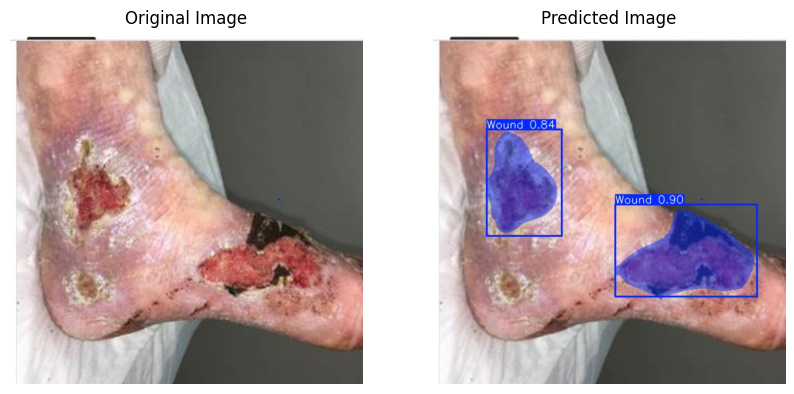

In [ ]:
import glob
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

# ✅ Load the trained model
model = YOLO("/content/runs/segment/train/weights/best.pt")

# ✅ Get all images from the test folder
image_folder = "/content/drive/MyDrive/FYPApplication2_yolo12/valid/images/*.jpg"
images = glob.glob(image_folder)

# ✅ Select a random image
if images:
    random_image = random.choice(images)
    print(f"Selected Image: {random_image}")

    # ✅ Run inference
    results = model(random_image)  # Returns a list of results

    # ✅ Create a directory for saving predictions
    save_path = "/content/drive/MyDrive/FYPApplication2_yolo12/predictions"
    os.makedirs(save_path, exist_ok=True)

    # ✅ Save the predicted image
    pred_filename = os.path.join(save_path, "predicted_" + os.path.basename(random_image))

    for result in results:
        result.save(filename=pred_filename)  # Correct save method

    # ✅ Read and display the original image
    original_img = cv2.imread(random_image)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))

    # ✅ Show Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis("off")

    # ✅ Read and display the Predicted Image
    predicted_img = cv2.imread(pred_filename)
    predicted_img = cv2.cvtColor(predicted_img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_img)
    plt.title("Predicted Image")
    plt.axis("off")

    plt.show()

else:
    print("No images found in the folder!")


Selected Image: /content/drive/MyDrive/FYPApplication2_yolo12/valid/images/bed_155_jpg.rf.d4f1ffbb1e5e80b34eec70a81a1c2217.jpg

image 1/1 /content/drive/MyDrive/FYPApplication2_yolo12/valid/images/bed_155_jpg.rf.d4f1ffbb1e5e80b34eec70a81a1c2217.jpg: 544x544 2 Wounds, 15.1ms
Speed: 2.2ms preprocess, 15.1ms inference, 3.0ms postprocess per image at shape (1, 3, 544, 544)


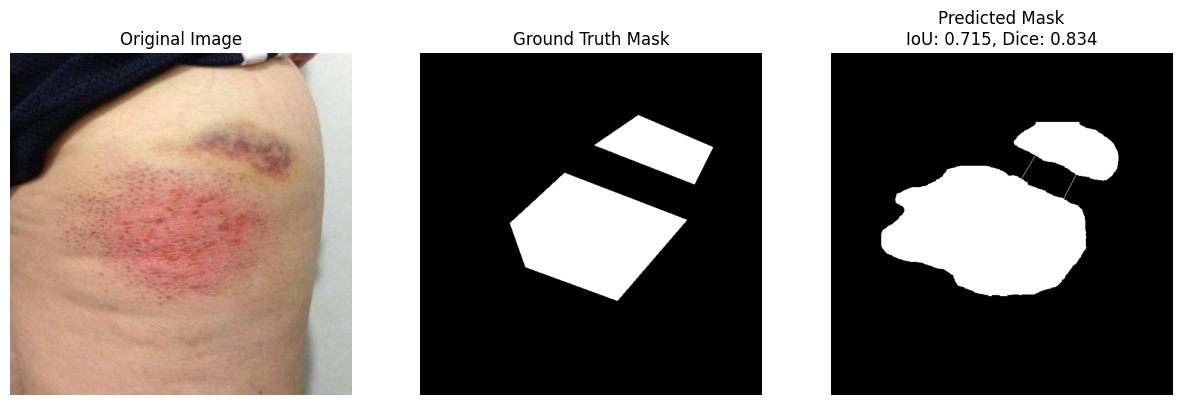

📌 **Numerical Metrics for bed_155_jpg.rf.d4f1ffbb1e5e80b34eec70a81a1c2217.jpg**
✔ Intersection over Union (IoU): 0.715
✔ Jaccard Index: 0.715
✔ Dice Score: 0.834


In [ ]:
import glob
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
import os

# ✅ Load the trained model
model = YOLO("/content/runs/segment/train/weights/best.pt")

# ✅ Get all images from the test folder
image_folder = "/content/drive/MyDrive/FYPApplication2_yolo12/valid/images/*.jpg"
images = glob.glob(image_folder)

# ✅ Select a random image
if images:
    random_image = random.choice(images)
    print(f"Selected Image: {random_image}")

    # ✅ Run inference
    results = model(random_image)  # Returns a list of results

    # ✅ Create a directory for saving predictions
    save_path = "/content/drive/MyDrive/FYPApplication2_yolo12/predictions"
    os.makedirs(save_path, exist_ok=True)

    # ✅ Save the predicted image
    pred_filename = os.path.join(save_path, "predicted_" + os.path.basename(random_image))

    for result in results:
        result.save(filename=pred_filename)  # Correct save method

    # ✅ Read Original Image
    original_img = cv2.imread(random_image)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # ✅ Load Ground Truth Mask from YOLO TXT Labels
    label_path = random_image.replace("/images/", "/labels/").replace(".jpg", ".txt")  # Find corresponding label file

    if os.path.exists(label_path):  # ✅ Ensure label exists
        h, w, _ = original_img.shape  # Image dimensions
        ground_truth_mask = np.zeros((h, w), dtype=np.uint8)  # Initialize empty mask

        with open(label_path, "r") as file:
            lines = file.readlines()
            for line in lines:
                data = line.strip().split()

                # ✅ Handle Bounding Box (5 values)
                if len(data) == 5:
                    class_id, x_center, y_center, bbox_width, bbox_height = map(float, data)

                    # Convert YOLO format (normalized) to pixel values
                    x_center, y_center = int(x_center * w), int(y_center * h)
                    bbox_width, bbox_height = int(bbox_width * w), int(bbox_height * h)

                    # Calculate bounding box coordinates
                    x_min = max(0, x_center - bbox_width // 2)
                    y_min = max(0, y_center - bbox_height // 2)
                    x_max = min(w, x_center + bbox_width // 2)
                    y_max = min(h, y_center + bbox_height // 2)

                    # Draw the bounding box as a white rectangle on the mask
                    cv2.rectangle(ground_truth_mask, (x_min, y_min), (x_max, y_max), 255, thickness=-1)

                # ✅ Handle Segmentation (More than 5 values)
                elif len(data) > 5:
                    class_id = int(data[0])
                    polygon_points = np.array(data[1:], dtype=np.float32).reshape(-1, 2)

                    # Convert normalized points to pixel values
                    polygon_points[:, 0] *= w
                    polygon_points[:, 1] *= h
                    polygon_points = polygon_points.astype(np.int32)

                    # Draw polygon mask
                    cv2.fillPoly(ground_truth_mask, [polygon_points], 255)

        ground_truth_mask = (ground_truth_mask > 0).astype(np.uint8)  # Convert to binary mask (0,1)

    else:
        print(f"❌ Ground truth label not found: {label_path}")
        ground_truth_mask = None  # Handle missing label case

    # ✅ Load Predicted Mask
    predicted_mask = np.zeros_like(original_img[:, :, 0])  # Initialize predicted mask

    for result in results:
        for mask in result.masks.xy:  # Extract polygons of masks
            points = np.array(mask, dtype=np.int32)
            cv2.fillPoly(predicted_mask, [points], 1)  # Fill mask with 1s

    # ✅ Compute Metrics
    if ground_truth_mask is not None:
        intersection = np.logical_and(ground_truth_mask, predicted_mask).sum()
        union = np.logical_or(ground_truth_mask, predicted_mask).sum()
        dice_score = (2.0 * intersection) / (ground_truth_mask.sum() + predicted_mask.sum()) if union > 0 else 0
        iou = intersection / union if union > 0 else 0
        jaccard_index = iou  # IoU and Jaccard are the same for segmentation
    else:
        dice_score, iou, jaccard_index = 0, 0, 0  # Default values if ground truth is missing

    # ✅ Display Results
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    if ground_truth_mask is not None:
        plt.imshow(ground_truth_mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(predicted_mask, cmap="gray")
    plt.title(f"Predicted Mask\nIoU: {iou:.3f}, Dice: {dice_score:.3f}")
    plt.axis("off")

    plt.show()

    # ✅ Print Numerical Metrics
    print(f"📌 **Numerical Metrics for {os.path.basename(random_image)}**")
    print(f"✔ Intersection over Union (IoU): {iou:.3f}")
    print(f"✔ Jaccard Index: {jaccard_index:.3f}")
    print(f"✔ Dice Score: {dice_score:.3f}")

else:
    print("No images found in the folder!")
